In [1]:
import sys
import os
from qiskit import QuantumCircuit
from qiskit.providers.basic_provider import BasicSimulator
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import Options, Session, SamplerV2 as Sampler
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister


Target Probabilities (from simulation): {'111': 0.855, '000': 0.145}


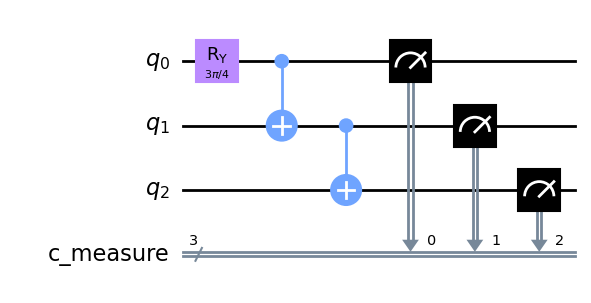

In [2]:
# 1. Create the Bell state (|ψ⟩ = (|00⟩ + |11⟩)/√2)
#circuit = QuantumCircuit(2, 2)
qr = QuantumRegister(3, name='q')
cr = ClassicalRegister(3, name='c_measure')

circuit = QuantumCircuit(qr, cr)
circuit.ry(np.pi*3/4, 0)
circuit.cx(0, 1)  # Apply CNOT gate
circuit.cx(1, 2)  # Apply CNOT gate
circuit.measure(qr, cr)

nshots = 1000
# use simulator
#backend = BasicSimulator()
backend = AerSimulator()
# make quantum circuit compatible to the backend
pm = generate_preset_pass_manager(backend = backend, optimization_level=3)
qc_comp = pm.run(circuit)

sampler = Sampler(mode=backend)
job = sampler.run([qc_comp], shots = nshots) # .result()[0].data.c_screen.get_counts()
couts = job.result()[0].data.c_measure.get_counts()

# Normalize target counts to probabilities
total_target_counts = sum(couts.values())
target_probabilities = {k: v / total_target_counts for k, v in couts.items()}
print("Target Probabilities (from simulation):", target_probabilities)

#circuit.draw(output="mpl", style="clifford", fold=40,  scale = 2.0, filename='circuit_3_4pi.svg')
circuit.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


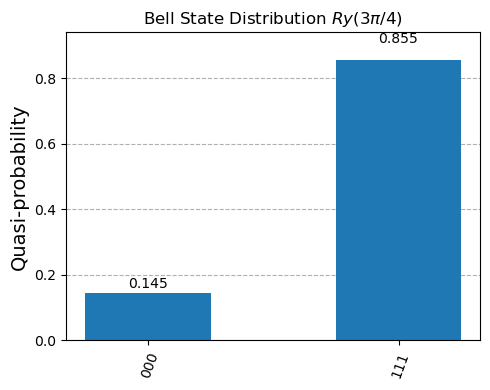

In [3]:
#plot_distribution(coutns, title= r'Bell State Distribution $Ry(3\pi/4)$', figsize=(5, 4), bar_labels=True, filename= 'qp_cc_3_4pi.svg')
plot_distribution(couts, title= r'Bell State Distribution $Ry(3\pi/4)$', figsize=(5, 4), bar_labels=True)

In [4]:
import numpy as np
import matplotlib.pyplot as plt # Import matplotlib for plotting
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator # Using AerSimulator for better compatibility
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from scipy.optimize import minimize
from collections import Counter
from qiskit_ibm_runtime import Options, Session, SamplerV2 as Sampler # Corrected Sampler import

# --- Global list to store KL divergence values for plotting the curve ---
kl_divergence_history = []
iteration_counter = 0 # Global counter for iterations

# --- Callback function for scipy.optimize.minimize ---
def callback_function(xk):
    """
    Callback function to print and record the KL divergence at each iteration.
    xk: Current parameters (angles) from the optimizer.
    """
    global iteration_counter # Declare global to modify the counter
    iteration_counter += 1

    # The objective function is called internally by minimize, so we need to
    # re-evaluate it to get the current KL divergence for printing.
    # We pass a dummy nshots_sim here, as the actual objective_function will use it.
    current_kl = objective_function(xk, target_probabilities, num_qubits, nshots_sim)
    kl_divergence_history.append(current_kl)

    # Print for the first iteration and then every 10 iterations
    if iteration_counter == 1 or iteration_counter % 10 == 0:
        print(f"Iteration {iteration_counter}: KL = {current_kl:.4f}")


# --- 1. Define the Target State Vector and derive Histogram/Probabilities ---
# For the Bell state (|00> + |11|)/sqrt(2), the state vector is [1/sqrt(2), 0, 0, 1/sqrt(2)]
#target_state_vector = Statevector([1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])
target_state_vector = Statevector(target_probabilities)
print("Target State Vector:", target_state_vector)

# Derive target probabilities from the state vector
# The probabilities are the squared magnitudes of the amplitudes
target_probabilities = target_state_vector.probabilities_dict()
print("Target Probabilities (from State Vector):", target_probabilities)

# Determine the number of qubits from the target probabilities
# Assuming all keys in target_probabilities have the same length
num_qubits = len(next(iter(target_probabilities)))
print(f"Inferred number of qubits: {num_qubits}")

# --- 2. Parametric Circuit Definition ---
def create_parametric_circuit(params, num_qubits):
    """
    Creates a quantum circuit with parametric Ry gates and a CNOT chain.
    The number of Ry gates should match the number of qubits.
    params: Array of angles for Ry gates, one for each qubit.
    """
    qr = QuantumRegister(num_qubits, name='q')
    cr = ClassicalRegister(num_qubits, name='c_measure')
    circuit = QuantumCircuit(qr, cr)

    # Apply parametric Ry gates to each qubit
    for i in range(num_qubits):
        circuit.ry(params[i], i)

    # Apply CNOT gates to entangle (simple chain entanglement for demonstration)
    # This part might need to be more sophisticated depending on the target state
    if num_qubits > 1:
        for i in range(num_qubits - 1):
            circuit.cx(i, i + 1)

    # Measure all qubits
    circuit.measure(qr, cr)
    return circuit

# --- 3. KL Divergence Calculation Function ---
def kl_divergence(p_dist, q_dist):
    """
    Calculates the Kullback-Leibler (KL) divergence D(P || Q).
    P is the target distribution (p_dist), Q is the circuit's distribution (q_dist).

    Args:
        p_dist (dict): Target probability distribution (keys are bitstrings, values are probabilities).
        q_dist (dict): Measured probability distribution from the circuit.

    Returns:
        float: KL divergence value.
    """
    kl_div = 0.0
    # Ensure both distributions have the same keys, filling missing with 0 for calculation
    # We iterate over the keys of the target distribution (P) as per KL definition D(P||Q)
    # If P(x) is 0, that term contributes 0 to the sum, regardless of Q(x).
    # If P(x) > 0 but Q(x) is 0, it contributes a large value (infinity in theory).
    
    # Get all possible outcomes from the union of keys to ensure comprehensive check
    all_keys = sorted(list(set(p_dist.keys()).union(set(q_dist.keys()))))

    for key in all_keys:
        p_val = p_dist.get(key, 0.0)
        q_val = q_dist.get(key, 0.0)

        # Add a small epsilon to avoid log(0) and division by zero
        epsilon = 1e-9

        if p_val > 0: # Only sum if target probability is non-zero
            if q_val == 0:
                # If q_val is 0 and p_val is non-zero, KL divergence is theoretically infinite.
                # In practice, we use a large number or epsilon to avoid inf.
                kl_div += p_val * np.log(p_val / epsilon)
            else:
                kl_div += p_val * np.log(p_val / q_val)
    return kl_div

# --- 4. Objective Function for Optimization ---
def objective_function(params, target_probabilities, num_qubits, nshots_sim):
    """
    Objective function to minimize for KL divergence.

    Args:
        params (np.array): Array of parameters for the parametric circuit.
        target_probabilities (dict): The target probability distribution.
        num_qubits (int): The number of qubits in the circuit.
        nshots_sim (int): Number of shots for the simulator.

    Returns:
        float: The KL divergence between the simulated and target distributions.
    """
    # Create and run the parametric circuit
    qc = create_parametric_circuit(params, num_qubits)

    # Use AerSimulator for running the circuit
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_comp = pm.run(qc)

    sampler = Sampler(mode=backend) # User's provided line
    job = sampler.run([qc_comp], shots=nshots_sim)
    
    result_counts = job.result()[0].data.c_measure.get_counts() # Corrected based on user's successful run

    # Normalize simulated counts to probabilities
    total_sim_counts = sum(result_counts.values())
    sim_probabilities = {k: v / total_sim_counts for k, v in result_counts.items()}

    # Generate all possible outcomes for n qubits
    all_possible_outcomes = [bin(i)[2:].zfill(num_qubits) for i in range(2**num_qubits)]

    for outcome in all_possible_outcomes:
        if outcome not in sim_probabilities:
            sim_probabilities[outcome] = 0.0

    # Calculate KL divergence
    kl = kl_divergence(target_probabilities, sim_probabilities)
    return kl

# --- 5. Optimization ---
# Initial guess for the parameters (angles in radians)
initial_params = np.array([np.pi/2] * num_qubits) # Start with pi/2 for all Ry gates

# Number of shots for each simulation during optimization
nshots_sim = 1000

print("\nStarting KL Divergence Optimization...")
# Reset history and counter before each optimization run
kl_divergence_history = []
iteration_counter = 0
result = minimize(
    objective_function,
    initial_params,
    args=(target_probabilities, num_qubits, nshots_sim),
    method='COBYLA', # A good choice for derivative-free optimization
    callback=callback_function, # Added callback
    tol=1e-6, # Tolerance for convergence
    options={'maxiter': 100, 'disp': True} # Display optimization progress
)

print("\n--- Optimization Results ---")
print("Optimized Parameters (radians):", result.x)
print("Optimized Parameters (degrees):", np.degrees(result.x).round(2))
print("Minimum KL Divergence:", result.fun)
print("Number of Iterations:", iteration_counter)
print("Optimization Success:", result.success)

print("\n--- KL Divergence Curve (per iteration) ---")
# Plotting the KL divergence curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(kl_divergence_history) + 1), kl_divergence_history, marker='o', linestyle='-')
plt.title('KL Divergence vs. Optimization Iteration')
plt.xlabel('Iteration')
plt.ylabel('KL Divergence')
plt.grid(True)
plt.yscale('log') # Use a log scale for better visualization of convergence
plt.tight_layout()
#plt.savefig('kl_divergence_curve.svg') # Save the plot as an SVG file
#print("KL divergence curve saved as 'kl_divergence_curve.svg'")


# --- Verify the optimized circuit ---
print("\n--- Verifying Optimized Circuit ---")
optimized_qc = create_parametric_circuit(result.x, num_qubits)
backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
optimized_qc_comp = pm.run(optimized_qc)

sampler = Sampler(mode=backend) # User's provided line
job = sampler.run([optimized_qc_comp], shots=nshots_sim)
final_counts = job.result()[0].data.c_measure.get_counts() # Corrected based on user's successful run

total_final_counts = sum(final_counts.values())
final_probabilities = {k: v / total_final_counts for k, v in final_counts.items()}

# Ensure all possible outcomes are present in final_probabilities for accurate KL calculation
all_possible_outcomes = [bin(i)[2:].zfill(num_qubits) for i in range(2**num_qubits)]
for outcome in all_possible_outcomes:
    if outcome not in final_probabilities:
        final_probabilities[outcome] = 0.0

print("Target Probabilities:", target_probabilities)
print("Optimized Circuit Probabilities:", final_probabilities)
print("Final KL Divergence (re-calculated):", kl_divergence(target_probabilities, final_probabilities))

# Draw the optimized circuit
print("\n--- Optimized Circuit Drawing ---")
optimized_qc.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


QiskitError: 'Invalid input data format for Statevector'

Target State Vector: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
Target Probabilities (from State Vector): {'00': 0.4999999999999999, '11': 0.4999999999999999}
Inferred number of qubits: 2

Starting Circuit Structure Optimization (CNOTs and Ry angles)...

Total possible individual CNOT operations: 2

--- Structure Optimization Iteration 1 ---
Optimizing Ry angles for current CNOTs: []
  Inner Iteration 1: KL = 1.4149
  Inner Iteration 10: KL = 0.6675
  Inner Iteration 20: KL = 0.7221
  Inner Iteration 30: KL = 0.7245
  Inner Ry optimization converged: True
KL with current CNOTs after Ry optimization: 0.7384
  Attempting to add CNOT: (1, 0). New CNOT config: [(1, 0)]
  Inner Iteration 1: KL = 2.5220
  Inner Iteration 10: KL = 0.0018
  Inner Iteration 20: KL = 0.0098
  Inner Iteration 30: KL = 0.0070
  Inner Iteration 40: KL = 0.0048
  Inner Ry optimization after add CNOT converged: True
  Added CNOT (1, 0) improved 

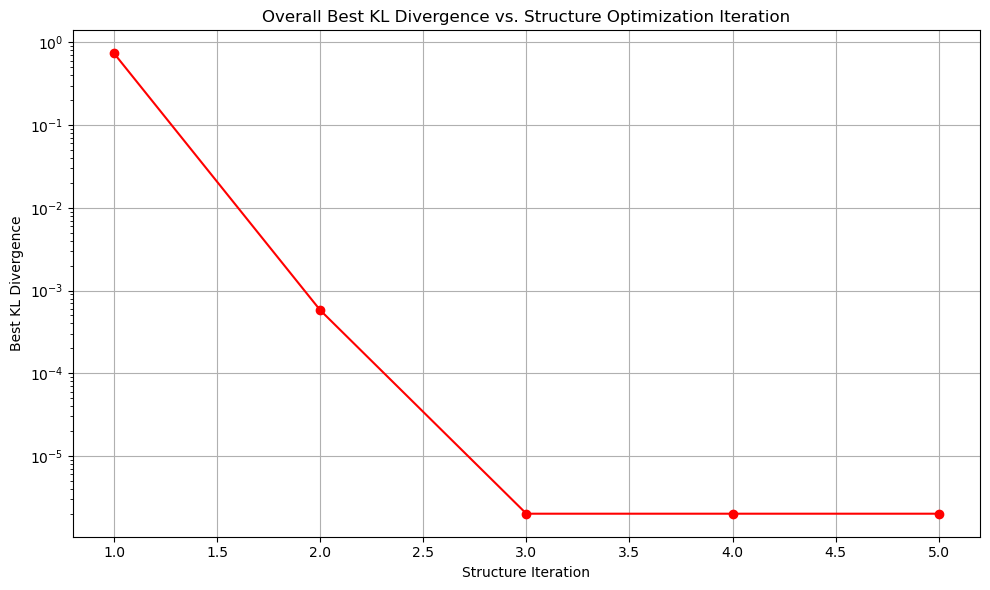

In [ ]:
import numpy as np
import matplotlib.pyplot as plt # Import matplotlib for plotting
import random # Import random for selecting CNOTs
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator # Using AerSimulator for better compatibility
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from scipy.optimize import minimize
from collections import Counter
from qiskit_ibm_runtime import Options, Session, SamplerV2 as Sampler # SamplerV2 import

# --- Global lists and counters for tracking optimization progress ---
kl_divergence_history_inner = [] # Stores KL for inner Ry optimization iterations
iteration_counter_inner = 0      # Global counter for inner Ry optimization iterations
kl_divergence_history_overall = [] # Stores best KL after each structure optimization step

# --- Callback function for scipy.optimize.minimize (inner loop) ---
def callback_function(xk):
    """
    Callback function to print and record the KL divergence at each inner Ry optimization iteration.
    xk: Current parameters (angles) from the optimizer.
    """
    global iteration_counter_inner
    iteration_counter_inner += 1

    # The objective function is called internally by minimize, so we need to
    # re-evaluate it to get the current KL divergence for printing.
    # We use the 'current_cnot_config_for_callback' global variable to pass the CNOT config.
    current_kl = objective_function(xk, target_probabilities, num_qubits, nshots_sim, current_cnot_config_for_callback)
    kl_divergence_history_inner.append(current_kl)

    # Print for the first iteration and then every 10 iterations
    if iteration_counter_inner == 1 or iteration_counter_inner % 10 == 0:
        print(f"  Inner Iteration {iteration_counter_inner}: KL = {current_kl:.4f}")


# --- 1. Define the Target State Vector and derive Histogram/Probabilities ---
# For the Bell state (|00> + |11|)/sqrt(2), the state vector is [1/sqrt(2), 0, 0, 1/sqrt(2)]
target_state_vector = Statevector([1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])
print("Target State Vector:", target_state_vector)

# Derive target probabilities from the state vector
# The probabilities are the squared magnitudes of the amplitudes
target_probabilities = target_state_vector.probabilities_dict()
print("Target Probabilities (from State Vector):", target_probabilities)

# Determine the number of qubits from the target probabilities
# Assuming all keys in target_probabilities have the same length
num_qubits = len(next(iter(target_probabilities)))
print(f"Inferred number of qubits: {num_qubits}")

# --- 2. Parametric Circuit Definition ---
def create_parametric_circuit(params_ry, num_qubits, cnot_config):
    """
    Creates a quantum circuit with parametric Ry gates and specified CNOT gates.
    params_ry: Array of angles for Ry gates, one for each qubit.
    cnot_config: A list of (control_qubit, target_qubit) tuples for CNOT gates.
    """
    qr = QuantumRegister(num_qubits, name='q')
    cr = ClassicalRegister(num_qubits, name='c_measure')
    circuit = QuantumCircuit(qr, cr)

    # Apply parametric Ry gates to each qubit
    for i in range(num_qubits):
        circuit.ry(params_ry[i], i)

    # Apply CNOT gates based on the provided configuration
    for control, target in cnot_config:
        circuit.cx(control, target)

    # Measure all qubits
    circuit.measure(qr, cr)
    return circuit

# --- 3. KL Divergence Calculation Function ---
def kl_divergence(p_dist, q_dist):
    """
    Calculates the Kullback-Leibler (KL) divergence D(P || Q).
    P is the target distribution (p_dist), Q is the circuit's distribution (q_dist).

    Args:
        p_dist (dict): Target probability distribution (keys are bitstrings, values are probabilities).
        q_dist (dict): Measured probability distribution from the circuit.

    Returns:
        float: KL divergence value.
    """
    kl_div = 0.0
    # Ensure both distributions have the same keys, filling missing with 0 for calculation
    all_keys = sorted(list(set(p_dist.keys()).union(set(q_dist.keys()))))

    for key in all_keys:
        p_val = p_dist.get(key, 0.0)
        q_val = q_dist.get(key, 0.0)

        # Add a small epsilon to avoid log(0) and division by zero
        epsilon = 1e-9

        if p_val > 0: # Only sum if target probability is non-zero
            if q_val == 0:
                # If q_val is 0 and p_val is non-zero, KL divergence is theoretically infinite.
                kl_div += p_val * np.log(p_val / epsilon)
            else:
                kl_div += p_val * np.log(p_val / q_val)
    return kl_div

# --- 4. Objective Function for Optimization ---
# Global variable to pass CNOT config to callback (due to minimize's args structure)
current_cnot_config_for_callback = []

def objective_function(params_ry, target_probabilities, num_qubits, nshots_sim, cnot_config):
    """
    Objective function to minimize for KL divergence.

    Args:
        params_ry (np.array): Array of parameters for the parametric Ry gates.
        target_probabilities (dict): The target probability distribution.
        num_qubits (int): The number of qubits in the circuit.
        nshots_sim (int): Number of shots for the simulator.
        cnot_config (list): List of (control, target) tuples for CNOT gates.

    Returns:
        float: The KL divergence between the simulated and target distributions.
    """
    # Create and run the parametric circuit
    qc = create_parametric_circuit(params_ry, num_qubits, cnot_config)

    # Use AerSimulator for running the circuit
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_comp = pm.run(qc)

    sampler = Sampler(mode=backend) # User's provided line
    job = sampler.run([qc_comp], shots=nshots_sim)
    
    result_counts = job.result()[0].data.c_measure.get_counts() # Corrected based on user's successful run

    # Normalize simulated counts to probabilities
    total_sim_counts = sum(result_counts.values())
    sim_probabilities = {k: v / total_sim_counts for k, v in result_counts.items()}

    # Generate all possible outcomes for n qubits
    all_possible_outcomes = [bin(i)[2:].zfill(num_qubits) for i in range(2**num_qubits)]

    for outcome in all_possible_outcomes:
        if outcome not in sim_probabilities:
            sim_probabilities[outcome] = 0.0

    # Calculate KL divergence
    kl = kl_divergence(target_probabilities, sim_probabilities)
    return kl

# --- 5. Outer Optimization Loop for Circuit Structure (CNOTs) ---
def optimize_circuit_structure(initial_ry_params, target_probabilities, num_qubits, nshots_sim, 
                               max_structure_iterations=10, max_inner_iterations=50):
    
    best_kl = float('inf')
    best_ry_params = initial_ry_params
    best_cnot_config = [] # Stores the CNOTs (control, target)

    # All possible individual CNOT operations (e.g., (0,1) and (1,0))
    all_possible_cnots_individual = []
    for c in range(num_qubits):
        for t in range(num_qubits):
            if c != t:
                all_possible_cnots_individual.append((c, t))

    print(f"\nTotal possible individual CNOT operations: {len(all_possible_cnots_individual)}")

    global kl_divergence_history_overall # Access global list for overall history

    for structure_iter in range(max_structure_iterations):
        print(f"\n--- Structure Optimization Iteration {structure_iter + 1} ---")

        # Set the current CNOT config for the objective function's callback
        global current_cnot_config_for_callback
        current_cnot_config_for_callback = list(best_cnot_config) # Copy to avoid modification issues

        # 1. Optimize Ry angles for the current best CNOT configuration
        print(f"Optimizing Ry angles for current CNOTs: {best_cnot_config}")
        global iteration_counter_inner
        iteration_counter_inner = 0 # Reset inner iteration counter
        kl_divergence_history_inner.clear() # Clear inner history for new optimization run

        result_ry_opt = minimize(
            objective_function,
            best_ry_params, # Use current best Ry params as initial guess
            args=(target_probabilities, num_qubits, nshots_sim, best_cnot_config),
            method='COBYLA',
            callback=callback_function,
            tol=1e-6,
            options={'maxiter': max_inner_iterations, 'disp': False} # Suppress inner disp
        )
        current_kl = result_ry_opt.fun
        current_ry_params = result_ry_opt.x
        print(f"  Inner Ry optimization converged: {result_ry_opt.success}") # Print convergence status

        print(f"KL with current CNOTs after Ry optimization: {current_kl:.4f}")

        # Update overall best if this configuration is better
        if current_kl < best_kl:
            best_kl = current_kl
            best_ry_params = current_ry_params
            # best_cnot_config is already the one that produced current_kl
        
        kl_divergence_history_overall.append(best_kl) # Record best KL for this structure iteration

        # 2. Try adding a random CNOT, respecting the "one per pair" rule
        # Max number of CNOTs (one per unique pair of qubits)
        max_cnots_allowed = num_qubits * (num_qubits - 1) // 2

        if len(best_cnot_config) < max_cnots_allowed:
            available_cnots_for_addition = []
            for cnot in all_possible_cnots_individual:
                reverse_cnot = (cnot[1], cnot[0])
                # Check if this CNOT or its reverse is already in the current best config
                if cnot not in best_cnot_config and reverse_cnot not in best_cnot_config:
                    available_cnots_for_addition.append(cnot)

            if available_cnots_for_addition:
                new_cnot = random.choice(available_cnots_for_addition)
                temp_cnot_config = best_cnot_config + [new_cnot]
                print(f"  Attempting to add CNOT: {new_cnot}. New CNOT config: {temp_cnot_config}")

                current_cnot_config_for_callback = list(temp_cnot_config)
                iteration_counter_inner = 0
                kl_divergence_history_inner.clear()

                result_add_cnot = minimize(
                    objective_function,
                    initial_ry_params, # Start Ry params from scratch for new CNOT config
                    args=(target_probabilities, num_qubits, nshots_sim, temp_cnot_config),
                    method='COBYLA',
                    callback=callback_function,
                    tol=1e-6,
                    options={'maxiter': max_inner_iterations, 'disp': False}
                )
                kl_after_add = result_add_cnot.fun
                print(f"  Inner Ry optimization after add CNOT converged: {result_add_cnot.success}") # Print convergence status


                if kl_after_add < best_kl:
                    print(f"  Added CNOT {new_cnot} improved KL from {best_kl:.4f} to {kl_after_add:.4f}")
                    best_kl = kl_after_add
                    best_ry_params = result_add_cnot.x
                    best_cnot_config = temp_cnot_config
                else:
                    print(f"  Adding CNOT {new_cnot} did not improve KL ({kl_after_add:.4f} vs {best_kl:.4f})")
            else:
                print("  No more unique CNOTs (or their reverses) to add.")

        # 3. Try removing a random CNOT (optional, but good for exploration)
        # This part remains largely the same as it removes from the *current* config,
        # which already adheres to the "one per pair" rule.
        if len(best_cnot_config) > 0 and structure_iter % 2 == 0: # Try removal less frequently
            cnot_to_remove = random.choice(best_cnot_config)
            temp_cnot_config = [c for c in best_cnot_config if c != cnot_to_remove]
            print(f"  Attempting to remove CNOT: {cnot_to_remove}. New CNOT config: {temp_cnot_config}")

            current_cnot_config_for_callback = list(temp_cnot_config)
            iteration_counter_inner = 0
            kl_divergence_history_inner.clear()

            result_remove_cnot = minimize(
                objective_function,
                initial_ry_params, # Start Ry params from scratch for new CNOT config
                args=(target_probabilities, num_qubits, nshots_sim, temp_cnot_config),
                method='COBYLA',
                callback=callback_function,
                tol=1e-6,
                options={'maxiter': max_inner_iterations, 'disp': False}
            )
            kl_after_remove = result_remove_cnot.fun
            print(f"  Inner Ry optimization after remove CNOT converged: {result_remove_cnot.success}") # Print convergence status


            if kl_after_remove < best_kl:
                print(f"  Removing CNOT {cnot_to_remove} improved KL from {best_kl:.4f} to {kl_after_remove:.4f}")
                best_kl = kl_after_remove
                best_ry_params = result_remove_cnot.x
                best_cnot_config = temp_cnot_config
            else:
                print(f"  Removing CNOT {cnot_to_remove} did not improve KL ({kl_after_remove:.4f} vs {best_kl:.4f})")
    
    return best_ry_params, best_cnot_config, best_kl

# --- Main Optimization Execution ---
# Initial guess for the Ry parameters (angles in radians)
initial_ry_params = np.array([np.pi/2] * num_qubits) # Start with pi/2 for all Ry gates

# Number of shots for each simulation during optimization
nshots_sim = 1000

# Perform the structure optimization
print("\nStarting Circuit Structure Optimization (CNOTs and Ry angles)...")
# Reset overall history before starting
kl_divergence_history_overall = []
optimized_ry_params, optimized_cnot_config, min_kl = optimize_circuit_structure(
    initial_ry_params, target_probabilities, num_qubits, nshots_sim,
    max_structure_iterations=5, # Number of times to try adding/removing CNOTs
    max_inner_iterations=50     # Max iterations for Ry optimization in each step
)

print("\n--- Final Optimization Results ---")
print("Optimized Ry Parameters (radians):", optimized_ry_params)
print("Optimized Ry Parameters (degrees):", np.degrees(optimized_ry_params).round(2))
print("Optimized CNOT Configuration:", optimized_cnot_config)
print("Minimum KL Divergence Achieved:", min_kl)

print("\n--- Overall KL Divergence Curve (per structure iteration) ---")
# Plotting the overall KL divergence curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(kl_divergence_history_overall) + 1), kl_divergence_history_overall, marker='o', linestyle='-', color='red')
plt.title('Overall Best KL Divergence vs. Structure Optimization Iteration')
plt.xlabel('Structure Iteration')
plt.ylabel('Best KL Divergence')
plt.grid(True)
plt.yscale('log') # Use a log scale for better visualization of convergence
plt.tight_layout()
plt.savefig('overall_kl_divergence_curve.svg') # Save the plot as an SVG file
print("Overall KL divergence curve saved as 'overall_kl_divergence_curve.svg'")


# --- Verify the final optimized circuit ---
print("\n--- Verifying Final Optimized Circuit ---")
final_optimized_qc = create_parametric_circuit(optimized_ry_params, num_qubits, optimized_cnot_config)
backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
final_optimized_qc_comp = pm.run(final_optimized_qc)

sampler = Sampler(mode=backend) # User's provided line
job = sampler.run([final_optimized_qc_comp], shots=nshots_sim)
final_counts = job.result()[0].data.c_measure.get_counts() # Corrected based on user's successful run

total_final_counts = sum(final_counts.values())
final_probabilities = {k: v / total_final_counts for k, v in final_counts.items()}

# Ensure all possible outcomes are present in final_probabilities for accurate KL calculation
all_possible_outcomes = [bin(i)[2:].zfill(num_qubits) for i in range(2**num_qubits)]
for outcome in all_possible_outcomes:
    if outcome not in final_probabilities:
        final_probabilities[outcome] = 0.0

print("Target Probabilities:", target_probabilities)
print("Optimized Circuit Probabilities (Final):", final_probabilities)
print("Final KL Divergence (re-calculated):", kl_divergence(target_probabilities, final_probabilities))

# Draw the optimized circuit
print("\n--- Final Optimized Circuit Drawing ---")
print(final_optimized_qc.draw(output='text')) # Changed to print text output for console compatibility


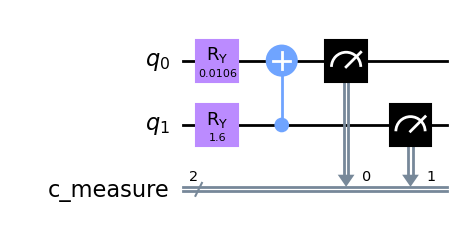

In [9]:
final_optimized_qc.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)

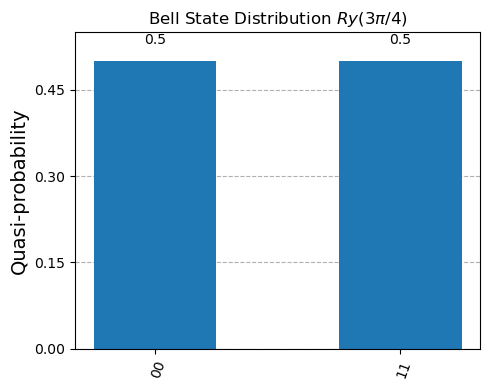

In [7]:
from qiskit.visualization import plot_histogram, plot_distribution
plot_distribution(final_counts, title= r'Bell State Distribution $Ry(3\pi/4)$', figsize=(5, 4), bar_labels=True)


--- STAGE 1: Topology Search (Fixed Initial State, Fixed CRX angles) ---

Initial Numeric State Vector for Topology Search: Statevector([0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j],
            dims=(2, 2, 2))

Initial Circuit for Topology Search (from Numeric State Vector):
          »
q_prep_0: »
          »
q_prep_1: »
          »
q_prep_2: »
          »
«          ┌─────────────────────────────────────────────────────────────────────────────────────┐
«q_prep_0: ┤0                                                                                    ├
«          │                                                                                     │
«q_prep_1: ┤1 State Preparation(0.35355,0.35355,0.35355,0.35355,0.35355,0.35355,0.35355,0.35355) ├
«          │                                                                                     │
«q_prep_2: ┤2                     

ValueError: Parameter mismatch: Expected 3 params (3 Ry + 0 CRX), but got 4

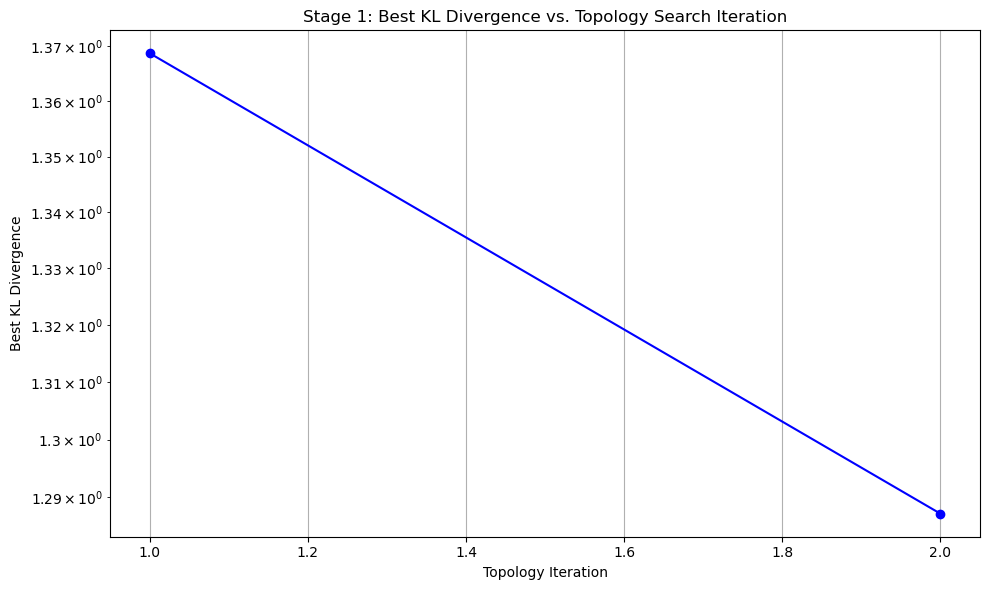

In [29]:
import numpy as np
import matplotlib.pyplot as plt # Import matplotlib for plotting
import random # Import random for selecting CNOTs
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator # Using AerSimulator for better compatibility
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from scipy.optimize import minimize
from collections import Counter
from qiskit_ibm_runtime import Options, Session, SamplerV2 as Sampler # SamplerV2 import
from qiskit.circuit.library import StatePreparation # Import StatePreparation

# --- Global lists and counters for tracking optimization progress ---
kl_divergence_history_inner = [] # Stores KL for inner parameter optimization iterations
iteration_counter_inner = 0      # Global counter for inner parameter optimization iterations
kl_divergence_history_overall = [] # Stores best KL after each structure optimization step

# --- Callback function for scipy.optimize.minimize (inner loop) ---
def callback_function(xk):
    """
    Callback function to print and record the KL divergence at each inner parameter optimization iteration.
    xk: Current parameters (angles) from the optimizer.
    """
    global iteration_counter_inner
    iteration_counter_inner += 1

    # The objective function is called internally by minimize, so we need to
    # re-evaluate it to get the current KL divergence for printing.
    # We use the 'current_cnot_config_for_callback' and 'initial_circuit_current_phase'
    # global variables to pass the circuit configuration.
    current_kl = objective_function_params_opt(
        xk,
        target_probabilities_current_phase,
        num_qubits,
        nshots_sim_current_phase,
        current_cnot_config_for_callback,
        initial_circuit_current_phase
    )
    kl_divergence_history_inner.append(current_kl)

    # Print for the first iteration and then every 10 iterations
    if iteration_counter_inner == 1 or iteration_counter_inner % 10 == 0:
        print(f"  Inner Iteration {iteration_counter_inner}: KL = {current_kl:.4f}")


# --- 1. Global Parameters and Target Definitions (will be updated per phase) ---
# These will be set dynamically based on the current optimization phase
target_probabilities_current_phase = {}
num_qubits = 0
nshots_sim_current_phase = 0
initial_circuit_current_phase = None # Stores the fixed part of the circuit (e.g., feature map)


# --- Helper function to create a circuit from a Statevector ---
def prepare_state_circuit(state_vector_obj):
    """
    Creates a QuantumCircuit that prepares the given Statevector.
    """
    num_q = state_vector_obj.num_qubits
    qr = QuantumRegister(num_q, name='q_prep')
    circuit = QuantumCircuit(qr)
    circuit.append(StatePreparation(state_vector_obj), qr)
    return circuit


# --- 2. Parametric Circuit Creation (Ry and CRX gates based on config) ---
def create_parametric_circuit(params, num_q, cnot_config, initial_circuit=None):
    """
    Creates a quantum circuit with an optional initial circuit, parametric Ry gates,
    and parametric CRX gates based on cnot_config.
    params: A single array containing [ry_angles_0...N-1, crx_angles_0...M-1]
    num_q: Number of qubits.
    cnot_config: A list of (control_qubit, target_qubit) tuples for CRX gates.
    initial_circuit: An optional QuantumCircuit to prepend (e.g., feature map).
    """
    qr = QuantumRegister(num_q, name='q')
    cr = ClassicalRegister(num_q, name='c_measure')
    circuit = QuantumCircuit(qr, cr)

    if initial_circuit:
        # Compose the initial circuit onto the main circuit
        # Ensure initial_circuit is composed on the correct number of qubits
        if initial_circuit.num_qubits != num_q:
            raise ValueError(f"Initial circuit has {initial_circuit.num_qubits} qubits, "
                             f"but target circuit has {num_q} qubits.")
        circuit.compose(initial_circuit, inplace=True)

    # Determine number of Ry and CRX parameters
    num_ry_params = num_q
    num_crx_params = len(cnot_config)

    # Validate parameter length
    if len(params) != (num_ry_params + num_crx_params):
        raise ValueError(f"Parameter mismatch: Expected {num_ry_params + num_crx_params} params "
                         f"({num_ry_params} Ry + {num_crx_params} CRX), but got {len(params)}")

    ry_angles = params[:num_ry_params]
    crx_angles = params[num_ry_params:]

    # Apply parametric Ry gates to each qubit
    for i in range(num_ry_params):
        circuit.ry(ry_angles[i], i)

    # Apply parametric CRX gates based on the provided configuration
    for idx, (control, target) in enumerate(cnot_config):
        circuit.crx(crx_angles[idx], control, target)

    # Measure all qubits
    circuit.measure(qr, cr)
    return circuit

# --- 3. KL Divergence Calculation Function ---
def kl_divergence(p_dist, q_dist):
    """
    Calculates the Kullback-Leibler (KL) divergence D(P || Q).
    P is the target distribution (p_dist), Q is the circuit's distribution (q_dist).

    Args:
        p_dist (dict): Target probability distribution (keys are bitstrings, values are probabilities).
        q_dist (dict): Measured probability distribution from the circuit.

    Returns:
        float: KL divergence value.
    """
    kl_div = 0.0
    # Ensure both distributions have the same keys, filling missing with 0 for calculation
    all_keys = sorted(list(set(p_dist.keys()).union(set(q_dist.keys()))))

    for key in all_keys:
        p_val = p_dist.get(key, 0.0)
        q_val = q_dist.get(key, 0.0)

        # Add a small epsilon to avoid log(0) and division by zero
        epsilon = 1e-9

        if p_val > 0: # Only sum if target probability is non-zero
            if q_val == 0:
                # If q_val is 0 and p_val is non-zero, KL divergence is theoretically infinite.
                kl_div += p_val * np.log(p_val / epsilon)
            else:
                kl_div += p_val * np.log(p_val / q_val)
    return kl_div

# --- 4. Objective Function for Ry and CRX Parameter Optimization ---
# Global variable to pass CNOT config to callback (due to minimize's args structure)
current_cnot_config_for_callback = []

def objective_function_params_opt(params, target_probs, num_q, nshots_sim_val, cnot_config, initial_circ):
    """
    Objective function to minimize for KL divergence by optimizing Ry and CRX parameters.

    Args:
        params (np.array): Array of parameters for the parametric Ry and CRX gates.
        target_probs (dict): The target probability distribution.
        num_q (int): The number of qubits in the circuit.
        nshots_sim_val (int): Number of shots for the simulator.
        cnot_config (list): List of (control, target) tuples for CRX gates.
        initial_circ (QuantumCircuit): The fixed part of the circuit (e.g., feature map).

    Returns:
        float: The KL divergence between the simulated and target distributions.
    """
    # Create and run the parametric circuit
    qc = create_parametric_circuit(params, num_q, cnot_config, initial_circuit=initial_circ)

    # Use AerSimulator for running the circuit
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_comp = pm.run(qc)

    sampler = Sampler(mode=backend) # User's provided line
    job = sampler.run([qc_comp], shots=nshots_sim_val)
    
    result_counts = job.result()[0].data.c_measure.get_counts()

    # Normalize simulated counts to probabilities
    total_sim_counts = sum(result_counts.values())
    sim_probabilities = {k: v / total_sim_counts for k, v in result_counts.items()}

    # Generate all possible outcomes for n qubits
    all_possible_outcomes = [bin(i)[2:].zfill(num_q) for i in range(2**num_q)]

    for outcome in all_possible_outcomes:
        if outcome not in sim_probabilities:
            sim_probabilities[outcome] = 0.0

    # Calculate KL divergence
    kl = kl_divergence(target_probs, sim_probabilities)
    return kl

# --- 5. Function to Evaluate Topology (Fixed Ry and CRX angles for this phase) ---
def evaluate_topology_kl(cnot_config, initial_circuit_for_eval, target_probs, num_q, nshots_sim_val):
    """
    Evaluates the KL divergence for a given CNOT configuration with a fixed initial circuit
    and fixed Ry and CRX angles. Used for topology search.
    """
    # Define fixed Ry and CRX angles for topology evaluation
    # Ry angles are 0 (inactive), CRX angles are pi (mimic CNOT)
    fixed_ry_angles = np.zeros(num_q)
    fixed_crx_angles = np.full(len(cnot_config), np.pi) if len(cnot_config) > 0 else np.array([])
    
    fixed_params = np.concatenate((fixed_ry_angles, fixed_crx_angles)) # Combine for create_parametric_circuit

    qc = create_parametric_circuit(fixed_params, num_q, cnot_config, initial_circuit=initial_circuit_for_topology_eval)

    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_comp = pm.run(qc)

    sampler = Sampler(mode=backend)
    job = sampler.run([qc_comp], shots=nshots_sim_val)
    
    result_counts = job.result()[0].data.c_measure.get_counts()

    total_sim_counts = sum(result_counts.values())
    sim_probabilities = {k: v / total_sim_counts for k, v in result_counts.items()}

    all_possible_outcomes = [bin(i)[2:].zfill(num_q) for i in range(2**num_q)]
    for outcome in all_possible_outcomes:
        if outcome not in sim_probabilities:
            sim_probabilities[outcome] = 0.0
    
    kl = kl_divergence(target_probs, sim_probabilities)
    return kl


# --- 6. Outer Optimization Loop for Circuit Structure (CNOTs) ---
def optimize_circuit_topology(initial_circuit_for_topology_eval, target_probs, num_q, nshots_sim_val, 
                              max_structure_iterations=10):
    
    best_kl = float('inf')
    best_cnot_config = [] # Stores the CNOTs (control, target)

    # All possible individual CNOT operations (e.g., (0,1) and (1,0))
    all_possible_cnots_individual = []
    for c in range(num_q):
        for t in range(num_q):
            if c != t:
                all_possible_cnots_individual.append((c, t))

    print(f"\nTotal possible individual CNOT operations: {len(all_possible_cnots_individual)}")

    global kl_divergence_history_overall # Access global list for overall history

    # Initialize with an empty CNOT config and evaluate its KL
    current_kl_empty_config = evaluate_topology_kl([], initial_circuit_for_topology_eval, target_probs, num_q, nshots_sim_val)
    best_kl = current_kl_empty_config
    kl_divergence_history_overall.append(best_kl)
    print(f"Initial KL with empty CNOT config: {best_kl:.4f}")

    for structure_iter in range(max_structure_iterations):
        print(f"\n--- Topology Optimization Iteration {structure_iter + 1} ---")
        
        improved_in_this_iteration = False # Flag to track if any improvement occurred

        # --- Phase 1: Try adding the single best CNOT ---
        best_cnot_to_add_in_this_iter = None
        best_kl_after_add_candidate = float('inf')

        available_cnots_for_addition = []
        for cnot in all_possible_cnots_individual:
            reverse_cnot = (cnot[1], cnot[0])
            # Check if this CNOT or its reverse is already in the current best config
            if cnot not in best_cnot_config and reverse_cnot not in best_cnot_config:
                available_cnots_for_addition.append(cnot)

        if available_cnots_for_addition:
            print(f"  Exploring additions to current CNOTs: {best_cnot_config}")
            for new_cnot_candidate in available_cnots_for_addition:
                temp_cnot_config = best_cnot_config + [new_cnot_candidate]
                kl_after_add = evaluate_topology_kl(temp_cnot_config, initial_circuit_for_topology_eval, target_probs, num_q, nshots_sim_val)
                
                if kl_after_add < best_kl_after_add_candidate:
                    best_kl_after_add_candidate = kl_after_add
                    best_cnot_to_add_in_this_iter = new_cnot_candidate
            
            if best_kl_after_add_candidate < best_kl:
                print(f"    Adding BEST CNOT {best_cnot_to_add_in_this_iter} improved KL from {best_kl:.4f} to {best_kl_after_add_candidate:.4f}")
                best_kl = best_kl_after_add_candidate
                best_cnot_config = best_cnot_config + [best_cnot_to_add_in_this_iter]
                improved_in_this_iteration = True
            else:
                print("    No single CNOT addition improved KL in this pass.")
        else:
            print("  No more unique CNOTs (or their reverses) to add.")

        # --- Phase 2: Try removing a random CNOT (less frequent, only if no improvement from additions) ---
        # This removal step is now a fallback if additions didn't improve, or if it's a removal-focused iter
        if not improved_in_this_iteration and len(best_cnot_config) > 0 and structure_iter % 2 == 0:
            cnot_to_remove = random.choice(best_cnot_config)
            temp_cnot_config = [c for c in best_cnot_config if c != cnot_to_remove]
            print(f"  Exploring removal: Attempting to remove CNOT: {cnot_to_remove}. New CNOT config: {temp_cnot_config}")

            kl_after_remove = evaluate_topology_kl(temp_cnot_config, initial_circuit_for_topology_eval, target_probs, num_q, nshots_sim_val)

            if kl_after_remove < best_kl:
                print(f"    Removing CNOT {cnot_to_remove} improved KL from {best_kl:.4f} to {kl_after_remove:.4f}")
                best_kl = kl_after_remove
                best_cnot_config = temp_cnot_config
                improved_in_this_iteration = True
            else:
                print(f"    Removing CNOT {cnot_to_remove} did not improve KL ({kl_after_remove:.4f} vs {best_kl:.4f})")
        
        # If no improvement in this entire structure iteration, break the loop
        if not improved_in_this_iteration:
            print("  No further improvement in this structure iteration. Exiting topology search early.")
            break 

        kl_divergence_history_overall.append(best_kl) # Record best KL for this structure iteration
    
    return best_cnot_config, best_kl

# --- Main Optimization Execution ---

# --- Stage 1: Topology Search ---
print("\n--- STAGE 1: Topology Search (Fixed Initial State, Fixed CRX angles) ---")

# Define the target for the topology search (e.g., 3-qubit GHZ state probabilities)
# This target is what the CNOT topology aims to help achieve
num_qubits_target = 3 # Setting to 3 qubits for the target
target_state_vector_stage1 = Statevector([1/np.sqrt(2), 0, 0, 0, 0, 0, 0, 1/np.sqrt(2)]) # 3-qubit GHZ state
target_probabilities_stage1 = target_state_vector_stage1.probabilities_dict()
num_qubits_stage1 = num_qubits_target # Ensure num_qubits matches the target
nshots_sim_stage1 = 1000

# Define the fixed initial numeric state vector for topology evaluation
# This is a 3-qubit uniform superposition state vector (all amplitudes 1/sqrt(8))
# You can change this to any 8-element complex array for your custom initial state
initial_state_vector_numeric_fixed = Statevector([1/np.sqrt(8)] * 8)
print(f"\nInitial Numeric State Vector for Topology Search: {initial_state_vector_numeric_fixed}")

# Convert the numeric state vector into a QuantumCircuit that prepares it
initial_circuit_for_topology_eval = prepare_state_circuit(initial_state_vector_numeric_fixed)
print(f"\nInitial Circuit for Topology Search (from Numeric State Vector):\n{initial_circuit_for_topology_eval.draw(output='text')}")


# Set global variables for objective function in this stage
target_probabilities_current_phase = target_probabilities_stage1
num_qubits = num_qubits_stage1
nshots_sim_current_phase = nshots_sim_stage1
initial_circuit_current_phase = None # Not used directly by objective_function_params_opt in topology eval

# Perform the structure optimization
print("\nStarting Circuit Topology Search...")
kl_divergence_history_overall = [] # Reset for overall topology history
optimized_cnot_config, min_kl_topology = optimize_circuit_topology(
    initial_circuit_for_topology_eval, # Pass the defined initial circuit
    target_probs=target_probabilities_stage1,
    num_q=num_qubits,
    nshots_sim_val=nshots_sim_stage1,
    max_structure_iterations=5 # Number of times to try adding/removing CNOTs
)

print("\n--- Stage 1 Final Results ---")
print("Optimized CNOT Configuration:", optimized_cnot_config)
print("Minimum KL Divergence Achieved (Topology Search):", min_kl_topology)

print("\n--- Stage 1 Overall KL Divergence Curve (per structure iteration) ---")
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(kl_divergence_history_overall) + 1), kl_divergence_history_overall, marker='o', linestyle='-', color='blue')
plt.title('Stage 1: Best KL Divergence vs. Topology Search Iteration')
plt.xlabel('Topology Iteration')
plt.ylabel('Best KL Divergence')
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.savefig('topology_kl_curve.svg')
print("Topology KL divergence curve saved as 'topology_kl_curve.svg'")


# --- Stage 2: Parametric Angle Optimization ---
print("\n--- STAGE 2: Parametric Angle Optimization (Fixed Topology, Feature Map Initial State) ---")

# Define the feature map initial circuit (this is the "untouched" initial state for angle opt)
num_qubits_stage2 = num_qubits # Use the same number of qubits as found in Stage 1
# Use the SAME initial state as for topology search, as requested
feature_map_circuit = initial_circuit_for_topology_eval # Now uses the prepared circuit from the numeric state vector
print(f"\nFeature Map Circuit (Same as Topology Initial State):\n{feature_map_circuit.draw(output='text')}")


# Define the target for Stage 2 (same 3-qubit GHZ state)
target_state_vector_stage2 = target_state_vector_stage1 # Use the same target as Stage 1
target_probabilities_stage2 = target_probabilities_stage1
nshots_sim_stage2 = 1000

# Set global variables for objective function in this stage
target_probabilities_current_phase = target_probabilities_stage2
num_qubits = num_qubits_stage2
nshots_sim_current_phase = nshots_sim_stage2
initial_circuit_current_phase = feature_map_circuit


# Initial guess for the Ry and CRX parameters (angles in radians) for Stage 2
# Num Ry params = num_qubits_stage2
# Num CRX params = len(optimized_cnot_config)
initial_ry_params_stage2 = np.full(num_qubits_stage2, np.pi/2) # Start Ry with pi/2
initial_crx_params_stage2 = np.full(len(optimized_cnot_config), np.pi) if len(optimized_cnot_config) > 0 else np.array([]) # Start CRX with pi (like CNOT)
initial_params_stage2 = np.concatenate((initial_ry_params_stage2, initial_crx_params_stage2))


print("\nStarting Parametric Angle Optimization...")
kl_divergence_history_inner = [] # Reset inner history for Stage 2
iteration_counter_inner = 0 # Reset inner counter for Stage 2

# Conditionally run minimize based on whether optimized_cnot_config is empty
if len(optimized_cnot_config) == 0:
    # If no CNOTs, only optimize Ry parameters.
    # The 'params' passed to objective_function_params_opt will only be Ry angles.
    # The cnot_config passed to create_parametric_circuit will be empty.
    print("  No CRX gates found in topology search. Optimizing Ry parameters only.")
    # Calculate KL for initial Ry params with empty CNOT config
    initial_kl_no_crx = objective_function_params_opt(
        initial_ry_params_stage2, # Only Ry params
        target_probabilities_stage2,
        num_qubits_stage2,
        nshots_sim_stage2,
        [], # Empty cnot_config
        feature_map_circuit
    )
    # Manually populate result_angle_opt for this case
    result_angle_opt = type('obj', (object,), {
        'x': initial_ry_params_stage2,
        'fun': initial_kl_no_crx,
        'success': True,
        'nit': 0 # Number of iterations
    })() # Create a dummy object to mimic OptimizeResult
    kl_divergence_history_inner.append(initial_kl_no_crx) # Add initial KL to history
else:
    # If CNOTs exist, proceed with full optimization of Ry and CRX
    result_angle_opt = minimize(
        objective_function_params_opt,
        initial_params_stage2,
        args=(target_probabilities_stage2, num_qubits_stage2, nshots_sim_stage2, optimized_cnot_config, feature_map_circuit),
        method='COBYLA',
        callback=callback_function,
        tol=1e-6,
        options={'maxiter': 100, 'disp': True} # Display optimization progress
    )

print("\n--- Stage 2 Final Results ---")
print("Optimized Ry and CRX Parameters (radians):", result_angle_opt.x)
# Split and print separately for clarity
# This logic needs to be robust for when optimized_cnot_config is empty
if len(optimized_cnot_config) == 0:
    final_ry_params = result_angle_opt.x
    final_crx_params = np.array([]) # Empty array if no CRX
else:
    final_ry_params = result_angle_opt.x[:num_qubits_stage2]
    final_crx_params = result_angle_opt.x[num_qubits_stage2:]

print("Optimized Ry Parameters (degrees):", np.degrees(final_ry_params).round(2))
print("Optimized CRX Parameters (degrees):", np.degrees(final_crx_params).round(2))

print("Final Optimized CNOT Configuration (from Stage 1):", optimized_cnot_config)
print("Minimum KL Divergence Achieved (Angle Optimization):", result_angle_opt.fun)
print("Number of Iterations (Angle Optimization):", result_angle_opt.nit) # Use .nit for iterations
print("Angle Optimization Success:", result_angle_opt.success)

print("\n--- Stage 2 KL Divergence Curve (per iteration) ---")
if len(kl_divergence_history_inner) > 0: # Only plot if there's data
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(kl_divergence_history_inner) + 1), kl_divergence_history_inner, marker='o', linestyle='-', color='green')
    plt.title('Stage 2: KL Divergence vs. Angle Optimization Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('KL Divergence')
    plt.grid(True)
    plt.yscale('log')
    plt.tight_layout()
    plt.savefig('angle_kl_curve.svg')
    print("Angle KL divergence curve saved as 'angle_kl_curve.svg'")
else:
    print("No angle optimization iterations to plot (CRX config was empty).")


# --- Verify the final optimized circuit from Stage 2 ---
print("\n--- Verifying Final Optimized Circuit (Stage 2) ---")
# Pass the correct parameters (Ry and CRX) based on the optimization result
final_optimized_qc_stage2 = create_parametric_circuit(result_angle_opt.x, num_qubits_stage2, optimized_cnot_config, initial_circuit=feature_map_circuit)
backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
final_optimized_qc_comp_stage2 = pm.run(final_optimized_qc_stage2)

sampler = Sampler(mode=backend) # User's provided line
job = sampler.run([final_optimized_qc_comp_stage2], shots=nshots_sim_stage2)
final_counts_stage2 = job.result()[0].data.c_measure.get_counts()

total_final_counts_stage2 = sum(final_counts_stage2.values())
final_probabilities_stage2 = {k: v / total_final_counts_stage2 for k, v in final_counts_stage2.items()}

all_possible_outcomes = [bin(i)[2:].zfill(num_qubits_stage2) for i in range(2**num_qubits_stage2)]
for outcome in all_possible_outcomes:
    if outcome not in final_probabilities_stage2:
        final_probabilities_stage2[outcome] = 0.0

print("Target Probabilities (Stage 2):", target_probabilities_stage2)
print("Optimized Circuit Probabilities (Stage 2 Final):", final_probabilities_stage2)
print("Final KL Divergence (Stage 2 re-calculated):", kl_divergence(target_probabilities_stage2, final_probabilities_stage2))

# Draw the optimized circuit
print("\n--- Final Optimized Circuit Drawing (Stage 2) ---")
print(final_optimized_qc_stage2.draw(output='text'))


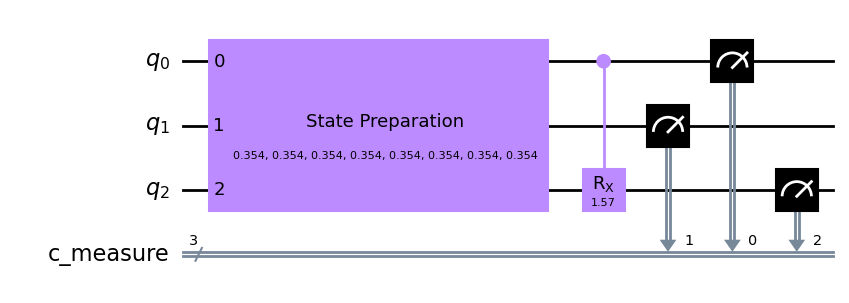

In [30]:
final_optimized_qc_stage2.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)

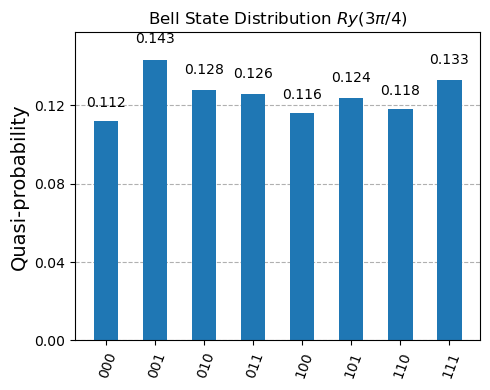

In [31]:
from qiskit.visualization import plot_histogram, plot_distribution
plot_distribution(final_counts_stage2, title= r'Bell State Distribution $Ry(3\pi/4)$', figsize=(5, 4), bar_labels=True)